# Notebook 10: Event Frequency and Schedule Robustness

**Research aim.** This notebook examines how event frequency and schedule regularity affect event detection, lag interpretation, event-profile recovery and event-aware volatility forecasting. The experiment keeps the scalar calibration and Known-DGP response shape fixed while comparing dense periodic, sparse periodic and sparse irregular calendars. Within each of 50 repetitions, identical epsilon and eta shocks are used for all schedules, so comparisons are paired. Step 2 is omitted: observable conditional structure is already examined in Notebook 02.

## 1. Common setup and schedule definitions

Event age 0-12 maps to direct response lags +1 to +13 under the frozen timing convention. Each pipeline uses a chronological train/test split, non-overlapping response windows and deployable forecasting inputs. The compact calculations below reuse the Notebook 06 workflow and the completed repeated-seed outputs.

In [1]:
%run "./06_experiment_workflow_helpers.ipynb"
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display
N_SEEDS=50; REP_SEED=20260722; STEPS=252; H=13; P_INDIVIDUAL=13; F_TOL=1e-10; COND_MAX=1e10
GC_PMAX={'dense_periodic':20,'sparse_periodic':41,'sparse_irregular':42}
RESULTS=Path('notebook10_results')
LABEL={'dense_periodic':'Dense periodic','sparse_periodic':'Sparse periodic','sparse_irregular':'Sparse irregular'}; COLOR={'dense_periodic':'tab:blue','sparse_periodic':'tab:orange','sparse_irregular':'tab:green'}
dense=make_case_config(reference_config,label='dense_periodic'); sparse=make_case_config(dense,{'events.period':42/252},label='sparse_periodic'); irregular=make_case_config(sparse,label='sparse_irregular')
CONFIG={'dense_periodic':dense,'sparse_periodic':sparse,'sparse_irregular':irregular}
STEPS_BY_CASE={'dense_periodic':np.arange(21,484,21),'sparse_periodic':np.arange(21,484,42),'sparse_irregular':np.array([21,52,113,134,203,249,276,302,364,396,449,483])}
case_results=pd.read_csv(RESULTS/'stage4_seed_case_analysis.csv'); tdmi_raw=pd.read_csv(RESULTS/'stage3_tdmi_curve.csv'); profiles=pd.read_csv(RESULTS/'stage4_profile_age_summary.csv')
profile_repeated=case_results[['market_seed','case_name','A_hat','lambda_hat','event_amplitude','event_decay_rate','A_error','lambda_error','parametric_profile_RMSE','nonparametric_profile_RMSE']].copy()
forecast_repeated=case_results[['market_seed','case_name','active_sigma_unaware_MAE','active_sigma_parametric_MAE','active_sigma_nonparametric_MAE','active_sigma_unaware_RMSE','active_sigma_parametric_RMSE','active_sigma_nonparametric_RMSE','active_sigma_parametric_MAE_gain_pct','active_sigma_nonparametric_MAE_gain_pct']].copy()
calibration_repeated=case_results[['market_seed','case_name','active_95_state_parametric_coverage','parametric_absolute_coverage_error','active_95_state_parametric_interval_score']].copy()
assert len(case_results)==150 and case_results.market_seed.nunique()==N_SEEDS and not case_results.duplicated(['market_seed','case_name']).any()
assert P_INDIVIDUAL==13 and derive_timing(dense)['response_horizon_steps']==12

[]


,check,passed
0,configuration and timing | Notebook 00 loaded ...,True
1,configuration and timing | reference_config no...,True
2,configuration and timing | reference_timing no...,True
3,configuration and timing | deep override only ...,True
4,configuration and timing | common shocks repro...,True
...,...,...
126,truth enabled contains complete Known-DGP outputs,True
127,truth inclusion leaves fitted forecasts unchanged,True
128,truth helper follows frozen forecast stage,True
129,negative powered-state bounds are not rooted,True


case_label                                          reference_n1
n                                                              1
event_amplitude                                             0.01
event_decay_rate                                            35.0
event_period                                            0.083333
                                                        ...     
known_dgp_active_95_state_coverage                      0.956044
known_dgp_active_sigma_MAE                              0.000674
known_dgp_active_sigma_RMSE                             0.000833
known_dgp_active_transformed_variance_sigma_MAE              NaN
known_dgp_active_transformed_variance_sigma_RMSE             NaN
Length: 69, dtype: object

Validation summary: 131 checks passed.


,schedule,events,mean spacing,minimum spacing,maximum spacing,periodic status,windows overlap
0,Dense periodic,23,21.0,21,21,True,False
1,Sparse periodic,12,42.0,42,42,True,False
2,Sparse irregular,12,42.0,21,69,False,False


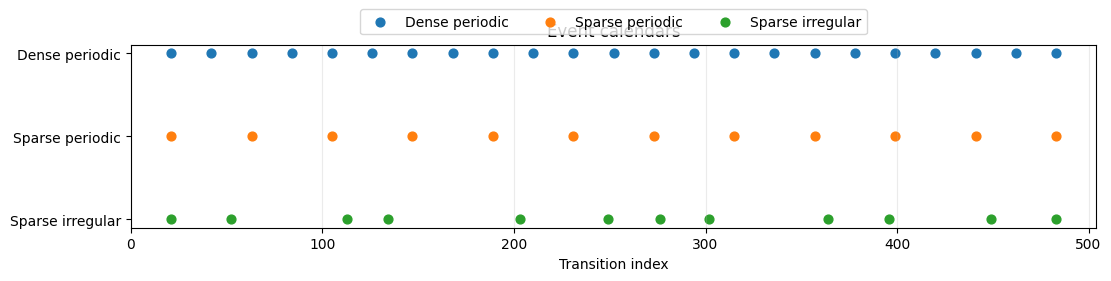

In [2]:
def no_overlap(x): return bool(np.all(np.diff(x)>=H))
schedule=pd.DataFrame([{'schedule':LABEL[k],'events':len(v),'mean spacing':np.diff(v).mean(),'minimum spacing':np.diff(v).min(),'maximum spacing':np.diff(v).max(),'periodic status':k!='sparse_irregular','windows overlap':not no_overlap(v)} for k,v in STEPS_BY_CASE.items()])
display(schedule.style.format({'mean spacing':'{:.1f}'}))
assert all(no_overlap(x) for x in STEPS_BY_CASE.values()) and len(STEPS_BY_CASE['sparse_periodic'])==len(STEPS_BY_CASE['sparse_irregular'])==12
fig,ax=plt.subplots(figsize=(11,2.7),constrained_layout=True)
for y,k in zip([2,1,0],LABEL): ax.scatter(STEPS_BY_CASE[k],np.full(len(STEPS_BY_CASE[k]),y),color=COLOR[k],s=40,label=LABEL[k])
ax.set(yticks=[0,1,2],yticklabels=[LABEL[k] for k in list(LABEL)[::-1]],xlabel='Transition index',xlim=(0,504),title='Event calendars')
ax.grid(axis='x',alpha=.25); ax.legend(ncol=3,loc='lower center',bbox_to_anchor=(.5,1.02)); plt.show()

## 2. Dense periodic analysis

Dense periodic has 23 events and a next-event boundary at 21 transitions. GC is **linear directional predictive evidence**: cumulative order p contains driver lags 1, ..., p. Individual lag j is tested conditionally on target history and all other event-history lags; it is not the same object as selected cumulative order p.

In [3]:
# Explicit historical GC directions. Forward: event history predicts powered-state target.
# Reverse: powered-state history predicts the binary predetermined event indicator (linear-probability-style diagnostic).
def lag_design(target_series,driver_series,p,common_max):
    target=np.asarray(target_series,float); driver=np.asarray(driver_series,float)
    if len(target)!=len(driver) or not (1<=p<=common_max<len(target)): raise ValueError('invalid GC lag specification')
    t=np.arange(common_max,len(target)); own=np.column_stack([target[t-j] for j in range(1,p+1)]); drv=np.column_stack([driver[t-j] for j in range(1,p+1)])
    columns=['const']+[f'target_lag_{j}' for j in range(1,p+1)]+[f'event_lag_{j}' for j in range(1,p+1)]
    X=np.column_stack([np.ones(len(t)),own,drv]); return target[t],X,columns

def run_gc_direction(target_series,driver_series,p,direction_label,common_max):
    y,Xu,columns=lag_design(target_series,driver_series,p,common_max); Xr=Xu[:,:p+1]
    rank_u,rank_r=np.linalg.matrix_rank(Xu),np.linalg.matrix_rank(Xr); cond=float(np.linalg.cond(Xu)); valid=(rank_u==Xu.shape[1] and rank_r==Xr.shape[1] and np.isfinite(cond) and cond<=COND_MAX)
    row={'direction':direction_label,'order':p,'n_observations':len(y),'n_columns':Xu.shape[1],'rank':rank_u,'condition_number':cond,'valid_rank':valid,'conditioning_ok':bool(np.isfinite(cond) and cond<=COND_MAX)}
    if not valid: return row
    unrestricted=sm.OLS(y,Xu).fit(method='qr'); q=p; R=np.zeros((q,Xu.shape[1])); R[:,p+1:]=np.eye(q); test=unrestricted.f_test(R); F=float(np.asarray(test.fvalue).squeeze()); p_value=float(np.asarray(test.pvalue).squeeze())
    if -F_TOL<=F<0: F,p_value=0.0,1.0
    if F<-F_TOL: raise RuntimeError(f'negative joint F beyond tolerance: {direction_label}, p={p}')
    assert np.isfinite(F) and F>=0 and 0<=p_value<=1
    row.update({'F':F,'p_value':p_value,'partial_r2':float((F*q)/(F*q+unrestricted.df_resid)),'aic':float(unrestricted.aic),'bic':float(unrestricted.bic)})
    return row

def series_pair(table,target_name,direction):
    state=table.state_i.to_numpy(float); event=table.event_i.to_numpy(float)
    if target_name=='change': state,event=np.diff(state),event[1:]
    return (state,event) if direction=='forward' else (event,state)

def gc_scan(table,case,target,direction,pmax):
    y,d=series_pair(table,target,direction); rows=[]
    for p in range(1,pmax+1):
        r=run_gc_direction(y,d,p,direction,pmax); r.update({'case':case,'target':target}); rows.append(r)
    return pd.DataFrame(rows)

def individual_lags(table,case,target):
    y,event=series_pair(table,target,'forward'); y,X,columns=lag_design(y,event,P_INDIVIDUAL,P_INDIVIDUAL); rank=np.linalg.matrix_rank(X); condition=float(np.linalg.cond(X))
    if rank!=X.shape[1]: raise RuntimeError(f'rank-deficient individual-lag design: {case}, {target}, forward, p={P_INDIVIDUAL}')
    fit=sm.OLS(y,X).fit(); rows=[]
    for j in range(1,P_INDIVIDUAL+1):
        index=1+P_INDIVIDUAL+(j-1); R=np.zeros((1,X.shape[1])); R[0,index]=1.0; test=fit.f_test(R); F=float(np.asarray(test.fvalue).squeeze()); p_value=float(np.asarray(test.pvalue).squeeze())
        if -F_TOL<=F<0: F,p_value=0.0,1.0
        if F<-F_TOL: raise RuntimeError(f'negative individual F beyond tolerance: {case}, {target}, j={j}')
        assert np.isfinite(F) and F>=0 and 0<=p_value<=1
        rows.append({'case':case,'target':target,'direction':'forward','individual_order':P_INDIVIDUAL,'lag':j,'coefficient':float(fit.params[index]),'partial_F':F,'p_value':p_value,'rank':rank,'n_columns':X.shape[1],'condition_number':condition})
    out=pd.DataFrame(rows); out['holm_p']=multipletests(out.p_value,method='holm')[1]; out['holm_reject']=out.holm_p<.05; return out

def make_table(case,seed):
    shocks=make_shock_bank(dense,seed=int(seed)); timing=derive_timing(CONFIG[case]); simulation=simulate_case(CONFIG[case],shocks,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing)['simulation']; return build_transition_table(simulation,CONFIG[case],timing)[0],simulation['transitions']
# Corrected canonical GC object: repeated direct-window selection plus representative full valid scans.
gc_rows=[]; individual_rows=[]; gc_design_diagnostics=[]; seeds=sorted(case_results.market_seed.unique())
for seed in seeds:
    shared=make_shock_bank(dense,seed=int(seed)); trans={}; tables={}
    for case in LABEL:
        timing=derive_timing(CONFIG[case]); sim=simulate_case(CONFIG[case],shared,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing)['simulation']; trans[case]=sim['transitions']; tables[case]=build_transition_table(sim,CONFIG[case],timing)[0]
    ref=trans['dense_periodic']; assert all(np.array_equal(x.epsilon.to_numpy(),ref.epsilon.to_numpy()) and np.array_equal(x.eta.to_numpy(),ref.eta.to_numpy()) for x in trans.values())
    for case,table in tables.items():
        for target in ['level','change']:
            for direction in ['forward','reverse']:
                scan=gc_scan(table,case,target,direction,P_INDIVIDUAL); scan['seed']=seed; gc_rows.extend(scan.to_dict('records')); gc_design_diagnostics.extend(scan[['case','seed','target','direction','order','n_observations','n_columns','rank','condition_number','valid_rank']].to_dict('records'))
            individual_rows.extend(individual_lags(table,case,target).assign(seed=seed).to_dict('records'))
gc_repeated=pd.DataFrame(gc_rows); individual_repeated=pd.DataFrame(individual_rows); gc_design_diagnostics=pd.DataFrame(gc_design_diagnostics)
assert len(gc_repeated)==N_SEEDS*3*2*2*P_INDIVIDUAL and gc_design_diagnostics.valid_rank.all()
assert individual_repeated.individual_order.eq(P_INDIVIDUAL).all() and individual_repeated['rank'].eq(individual_repeated.n_columns).all() and individual_repeated.partial_F.ge(0).all()

### Step 1 - GC and TDMI analysis

Reverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

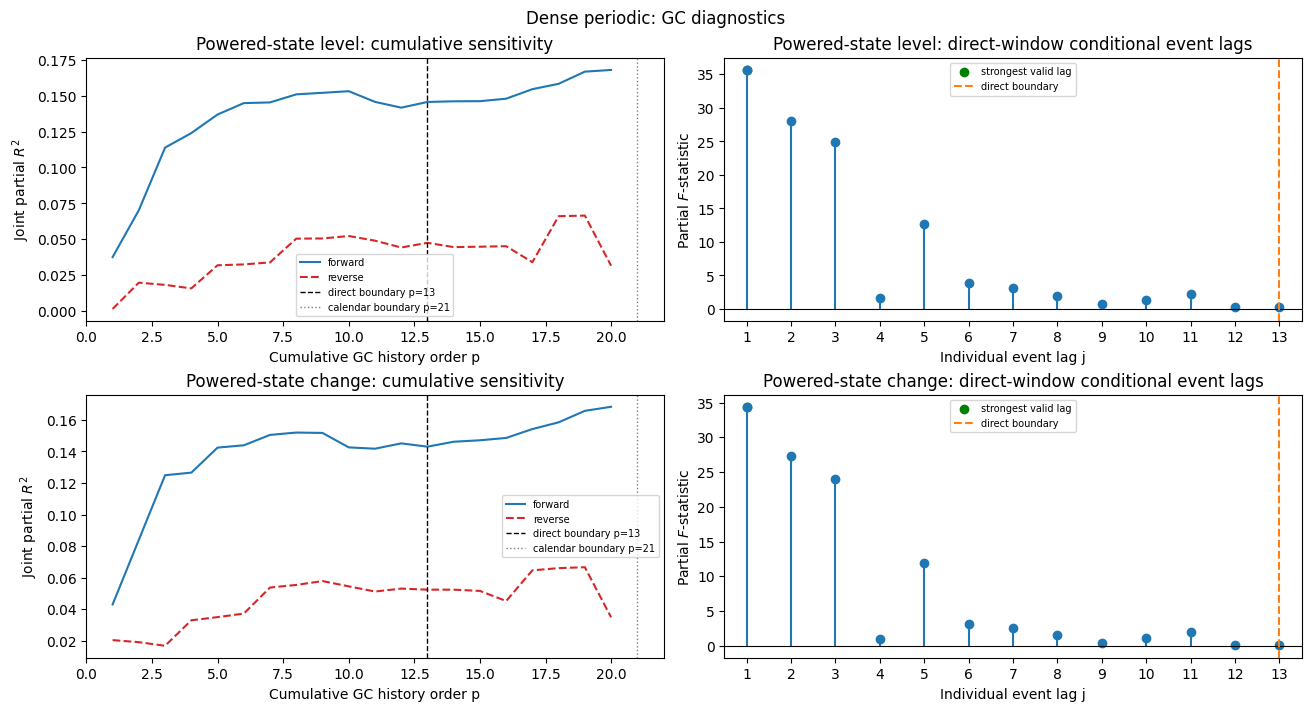

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,6,3,20,19.9091,0.0000,0.1138
1,level,reverse,20,20,19,0.7025,0.8247,0.0316
2,change,forward,5,3,20,22.0725,0.0000,0.1249
3,change,reverse,20,20,19,0.7782,0.7407,0.0349


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0013,35.6528,0.0000,0.0000,True
1,change,1,0.0013,34.3912,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,6.0000,2.0000,0.9800,0.0753,1.0000,32.4762,1.0000
1,level,7.0000,2.0000,1.0000,0.0721,1.0000,31.9281,1.0000


lag,1,2,3,4,5
target,,,,,
change,32,13,3,1,1
level,28,15,5,1,1


In [4]:
def representative_gc(case):
    table,_=make_table(case,REP_SEED); scans=[]
    for target in ['level','change']:
        for direction in ['forward','reverse']:
            scans.append(gc_scan(table,case,target,direction,GC_PMAX[case]))
    return table,pd.concat(scans,ignore_index=True),pd.concat([individual_lags(table,case,t) for t in ['level','change']],ignore_index=True)
def selection_summary(scan):
    valid=scan.loc[scan.valid_rank].dropna(subset=['aic','bic','partial_r2']); a=valid.loc[valid.aic.idxmin()]; b=valid.loc[valid.bic.idxmin()]; m=valid.loc[valid.partial_r2.idxmax()]
    return {'AIC order':int(a.order),'BIC order':int(b.order),'max partial R2 order':int(m.order),'joint F':float(b.F),'joint p':float(b.p_value),'partial R2':float(b.partial_r2)}
def show_gc(case):
    _,scans,individual=representative_gc(case); boundary={'dense_periodic':21,'sparse_periodic':42}.get(case); fig,axes=plt.subplots(2,2,figsize=(13,7),constrained_layout=True); order_rows=[]; strongest=[]
    for r,target in enumerate(['level','change']):
        for direction,style,col in [('forward','-','tab:blue'),('reverse','--','tab:red')]:
            d=scans.query('target==@target and direction==@direction and valid_rank'); axes[r,0].plot(d.order,d.partial_r2,style,color=col,label=direction); order_rows.append({'target':target,'direction':direction,**selection_summary(d)})
        axes[r,0].axvline(13,color='black',ls='--',lw=1,label='direct boundary p=13')
        if boundary: axes[r,0].axvline(boundary,color='grey',ls=':',lw=1,label=f'calendar boundary p={boundary}')
        axes[r,0].set(xlabel='Cumulative GC history order p',ylabel='Joint partial $R^2$',title=f'Powered-state {target}: cumulative sensitivity'); axes[r,0].legend(fontsize=7)
        d=individual.query('target==@target'); top=d.loc[d.partial_F.idxmax()]; strongest.append({'target':target,'lag j':int(top.lag),'coefficient':top.coefficient,'partial F':top.partial_F,'raw p':top.p_value,'Holm p':top.holm_p,'survives Holm':top.holm_reject})
        axes[r,1].stem(d.lag,d.partial_F,basefmt=' ',linefmt='tab:blue',markerfmt='o'); axes[r,1].scatter(top.lag,top.partial_F,color='green',label='strongest valid lag'); axes[r,1].axhline(0,color='black',lw=.8); axes[r,1].axvline(13,color='tab:orange',ls='--',label='direct boundary')
        axes[r,1].set(xlim=(.5,13.5),xticks=np.arange(1,14),xlabel='Individual event lag j',ylabel='Partial $F$-statistic',title=f'Powered-state {target}: direct-window conditional event lags'); axes[r,1].legend(fontsize=7)
    fig.suptitle(f'{LABEL[case]}: GC diagnostics'); plt.show(); display(pd.DataFrame(order_rows).style.format(precision=4)); display(pd.DataFrame(strongest).style.format(precision=4))
    d=gc_repeated.query('case==@case and direction=="forward" and valid_rank'); group=d.groupby(['seed','target']); selected=group.apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series).reset_index(); ind=individual_repeated.query('case==@case').sort_values('partial_F').groupby(['seed','target'],group_keys=False).tail(1)
    across=selected.groupby('target').agg(median_AIC_order=('AIC order','median'),median_BIC_order=('BIC order','median'),rejection_rate=('joint p',lambda x:(x<.05).mean()),median_partial_R2=('partial R2','median')).reset_index().merge(ind.groupby('target').agg(modal_strongest_j=('lag','median'),median_strongest_F=('partial_F','median'),Holm_survival_rate=('holm_reject','mean')).reset_index(),on='target'); display(across.style.format(precision=4)); display(ind.groupby(['target','lag']).size().unstack(fill_value=0))
display(Markdown("### Step 1 - GC and TDMI analysis\n\nReverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality."))
show_gc('dense_periodic')

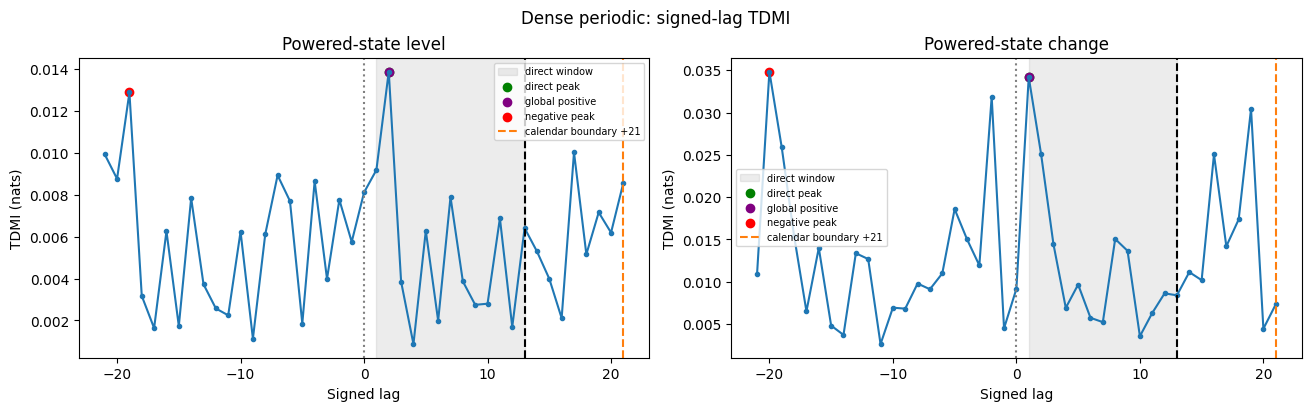

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,2,0.0139,2,0.0139,-19,True,False
1,change,1,0.0342,1,0.0342,-20,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.2800,0.7200,1.0758
1,level,0.0200,0.9800,1.1636


In [5]:
def tdmi_seed_metrics(group):
    rows=[]
    for target,d in group.groupby('target'):
        pos=d.query('lag>0'); direct=pos.query('lag<=13'); outside=pos.query('lag>13'); best=pos.loc[pos.mutual_information.idxmax()]; dmax=direct.mutual_information.max(); omax=outside.mutual_information.max(); neg=d.query('lag<0').loc[d.query('lag<0').mutual_information.idxmax()]
        rows.append({'target':target,'direct_lag':int(direct.loc[direct.mutual_information.idxmax(),'lag']),'direct_max':dmax,'global_positive_lag':int(best.lag),'global_positive_max':best.mutual_information,'negative_lag':int(neg.lag),'negative_max':neg.mutual_information,'global_positive_inside_direct':bool(best.lag<=13),'alias_dominates':bool(omax>dmax),'alias_strength_ratio':np.nan if dmax<=0 else omax/dmax,'scan_boundary':bool(abs(best.lag)==d.lag.abs().max())})
    return pd.DataFrame(rows)
tdmi_repeated=pd.concat([tdmi_seed_metrics(g).assign(seed=s,case=c) for (s,c),g in tdmi_raw.groupby(['market_seed','case_name'])],ignore_index=True)
assert len(tdmi_repeated)==N_SEEDS*3*2 and tdmi_repeated.alias_dominates.isin([True,False]).all() and tdmi_repeated.global_positive_inside_direct.isin([True,False]).all()
def show_tdmi(case):
    seed=REP_SEED if REP_SEED in set(tdmi_raw.market_seed) else tdmi_raw.market_seed.min(); period=21 if case=='dense_periodic' else 42; fig,axes=plt.subplots(1,2,figsize=(13,4),constrained_layout=True); rows=[]
    for ax,target in zip(axes,['level','change']):
        d=tdmi_raw.query('market_seed==@seed and case_name==@case and target==@target and lag.between(-@period,@period)').sort_values('lag'); metric=tdmi_seed_metrics(d).iloc[0]; direct=d.query('lag==@metric.direct_lag').iloc[0]; pos=d.query('lag==@metric.global_positive_lag').iloc[0]; neg=d.query('lag==@metric.negative_lag').iloc[0]
        ax.plot(d.lag,d.mutual_information,marker='o',ms=3); ax.axvline(0,color='grey',ls=':'); ax.axvspan(1,13,color='grey',alpha=.15,label='direct window'); ax.axvline(13,color='black',ls='--');
        for q,c,l in [(direct,'green','direct peak'),(pos,'purple','global positive'),(neg,'red','negative peak')]: ax.scatter(q.lag,q.mutual_information,color=c,label=l)
        if case!='sparse_irregular': ax.axvline(period,color='tab:orange',ls='--',label=f'calendar boundary +{period}')
        ax.set(title=f'Powered-state {target}',xlabel='Signed lag',ylabel='TDMI (nats)'); ax.legend(fontsize=7); rows.append({'target':target,'direct lag':metric.direct_lag,'direct TDMI':metric.direct_max,'global positive lag':metric.global_positive_lag,'global positive TDMI':metric.global_positive_max,'negative lag':metric.negative_lag,'global inside direct':metric.global_positive_inside_direct,'scan boundary':metric.scan_boundary})
    fig.suptitle(f'{LABEL[case]}: signed-lag TDMI'); plt.show(); display(pd.DataFrame(rows).style.format(precision=4)); d=tdmi_repeated.query('case==@case'); display(d.groupby('target').agg(global_positive_inside_direct_rate=('global_positive_inside_direct','mean'),outside_window_dominance_rate=('alias_dominates','mean'),median_outside_direct_ratio=('alias_strength_ratio','median')).reset_index().style.format(precision=4))
show_tdmi('dense_periodic')

### Step 3 - Event-weight recovery

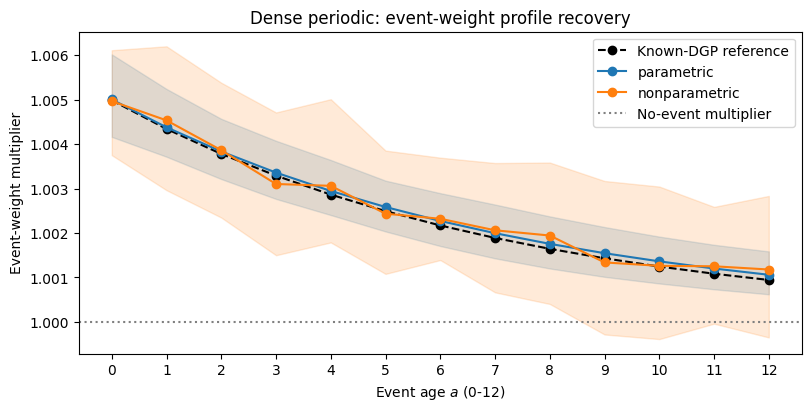

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.01004,0.00004,35.00000,33.48436,-1.51564,0.00034,0.00097


In [6]:
def show_profile(case):
    fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True); d=profiles.query('case_name==@case').sort_values('event_age'); truth=d.groupby('event_age').true_multiplier.first(); ax.plot(truth.index,truth.values,color='black',ls='--',marker='o',label='Known-DGP reference')
    for e,c in [('parametric','tab:blue'),('nonparametric','tab:orange')]: x=d.query('estimator==@e'); ax.plot(x.event_age,x.estimated_multiplier_mean,color=c,marker='o',label=e); ax.fill_between(x.event_age,x.estimated_multiplier_q05,x.estimated_multiplier_q95,color=c,alpha=.16)
    ax.axhline(1,color='grey',ls=':',label='No-event multiplier'); ax.set(xticks=np.arange(13),xlabel='Event age $a$ (0-12)',ylabel='Event-weight multiplier',title=f'{LABEL[case]}: event-weight profile recovery'); ax.legend(); plt.show(); display(Markdown('Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.'))
    z=profile_repeated.query('case_name==@case'); row=z.iloc[0]; display(pd.DataFrame([{'true amplitude':row.event_amplitude,'estimated amplitude':z.A_hat.mean(),'amplitude error':z.A_error.mean(),'true decay':row.event_decay_rate,'estimated decay':z.lambda_hat.mean(),'decay error':z.lambda_error.mean(),'parametric profile RMSE':z.parametric_profile_RMSE.mean(),'non-parametric profile RMSE':z.nonparametric_profile_RMSE.mean()}]).style.format(precision=5))
display(Markdown("### Step 3 - Event-weight recovery"))
show_profile('dense_periodic')

### Step 4 - Volatility forecasting

### Step 5 - Prediction accuracy and calibration

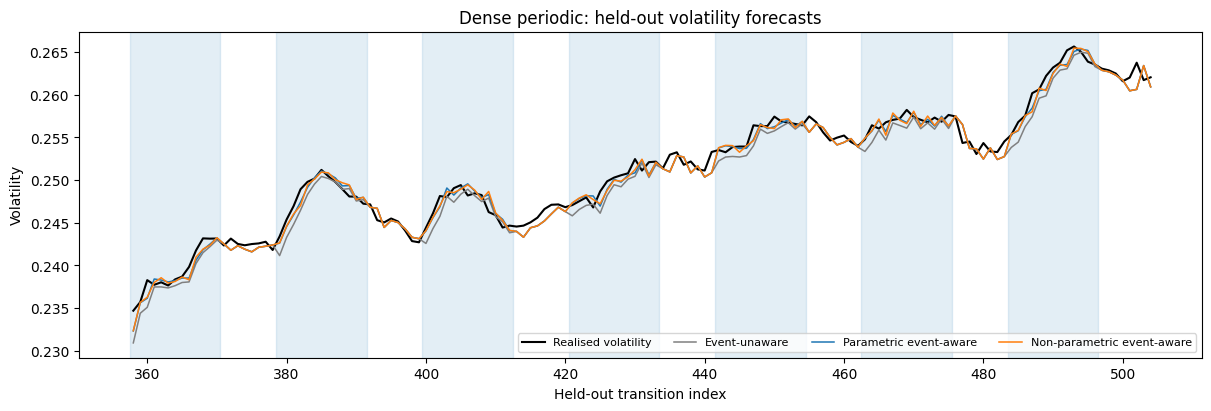

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0012,0.0009,0.0009,25.1875,22.1318,0.9470,0.0259,0.0042


In [7]:
def representative_forecast(case):
    table,_=make_table(case,REP_SEED); timing=derive_timing(CONFIG[case]); split=create_chronological_split(table,timing); baseline=fit_event_free_baseline(split['train'],CONFIG[case],build_baseline_features); profile=estimate_event_profiles(split['train'],baseline,CONFIG[case],timing,build_baseline_features); forecasts=construct_forecasts(split['test'],baseline,profile,CONFIG[case],timing,build_baseline_features); assert {'state_next','sigma_next','omega','eta'}.isdisjoint(forecasts.columns); return evaluate_forecasts(forecasts,split['test'],CONFIG[case])['evaluation']
def show_forecast(case):
    d=representative_forecast(case); fig,ax=plt.subplots(figsize=(12,4),constrained_layout=True); ax.plot(d.target_i,d.sigma_next,color='black',lw=1.5,label='Realised volatility')
    for c,l,col in [('sigma_forecast_unaware','Event-unaware','grey'),('sigma_forecast_parametric','Parametric event-aware','tab:blue'),('sigma_forecast_nonparametric','Non-parametric event-aware','tab:orange')]: ax.plot(d.target_i,d[c],color=col,lw=1.1,label=l)
    active=d.event_active_i.eq(1).to_numpy(); starts=d.loc[active&~np.r_[False,active[:-1]],'target_i']; ends=d.loc[active&~np.r_[active[1:],False],'target_i']; [ax.axvspan(a-.5,b+.5,color=COLOR[case],alpha=.12) for a,b in zip(starts,ends)]
    ax.set(xlabel='Held-out transition index',ylabel='Volatility',title=f'{LABEL[case]}: held-out volatility forecasts'); ax.legend(ncol=4,fontsize=8); plt.show(); display(Markdown('The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.'))
    z=forecast_repeated.query('case_name==@case').merge(calibration_repeated.query('case_name==@case'),on=['market_seed','case_name']); display(pd.DataFrame([{'unaware MAE':z.active_sigma_unaware_MAE.mean(),'parametric MAE':z.active_sigma_parametric_MAE.mean(),'non-parametric MAE':z.active_sigma_nonparametric_MAE.mean(),'unaware RMSE':z.active_sigma_unaware_RMSE.mean(),'parametric RMSE':z.active_sigma_parametric_RMSE.mean(),'non-parametric RMSE':z.active_sigma_nonparametric_RMSE.mean(),'parametric MAE gain (%)':z.active_sigma_parametric_MAE_gain_pct.median(),'non-parametric MAE gain (%)':z.active_sigma_nonparametric_MAE_gain_pct.median(),'parametric 95% coverage':z.active_95_state_parametric_coverage.mean(),'coverage error':z.parametric_absolute_coverage_error.mean(),'interval score':z.active_95_state_parametric_interval_score.mean()}]).style.format(precision=4))
display(Markdown("### Step 4 - Volatility forecasting\n\n### Step 5 - Prediction accuracy and calibration"))
show_forecast('dense_periodic')

Dense-periodic finding: interpret forward and reverse predictive diagnostics from the corrected tables above. Event-aware forecasting is evaluated as out-of-sample predictive performance, not structural recovery.

## 3. Sparse periodic analysis

Sparse periodic has 12 events and a deterministic next-event boundary at 42 transitions. The same four-step workflow is retained; the smaller event count affects precision and must not be confused with a pure periodicity effect.

### Step 1 - GC and TDMI analysis

Reverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

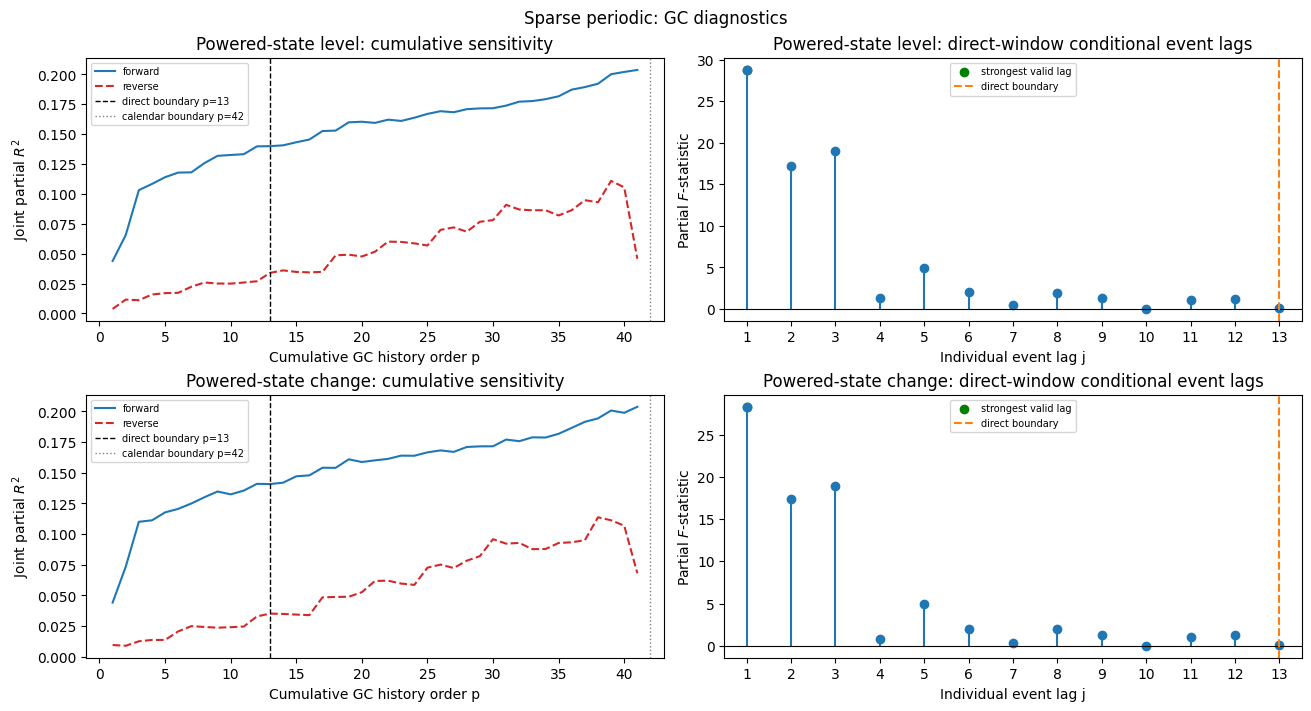

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,4,3,41,17.0332,0.0000,0.1032
1,level,reverse,41,41,39,0.4305,0.9992,0.0458
2,change,forward,3,3,41,18.2535,0.0000,0.1100
3,change,reverse,41,41,38,0.6542,0.9512,0.0681


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0016,28.7664,0.0000,0.0000,True
1,change,1,0.0016,28.2816,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,6.0000,1.0000,0.9400,0.0271,1.0000,16.9268,0.9600
1,level,7.0000,1.0000,0.9600,0.0270,1.0000,16.5931,0.9600


lag,1,2,3,4,5,6,8
target,,,,,,,
change,27,8,4,3,5,1,2
level,27,9,4,3,4,1,2


In [8]:
display(Markdown("### Step 1 - GC and TDMI analysis\n\nReverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality."))
show_gc('sparse_periodic')

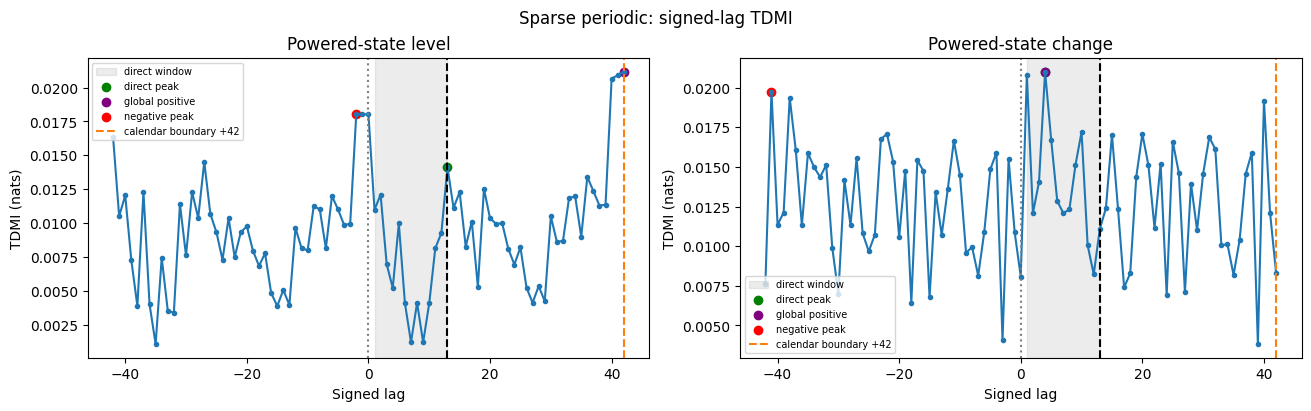

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,13,0.0141,42,0.0212,-2,False,True
1,change,4,0.0210,4,0.0210,-41,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.8000,0.2000,0.9120
1,level,0.3000,0.7000,1.2014


In [9]:
show_tdmi('sparse_periodic')

### Step 3 - Event-weight recovery

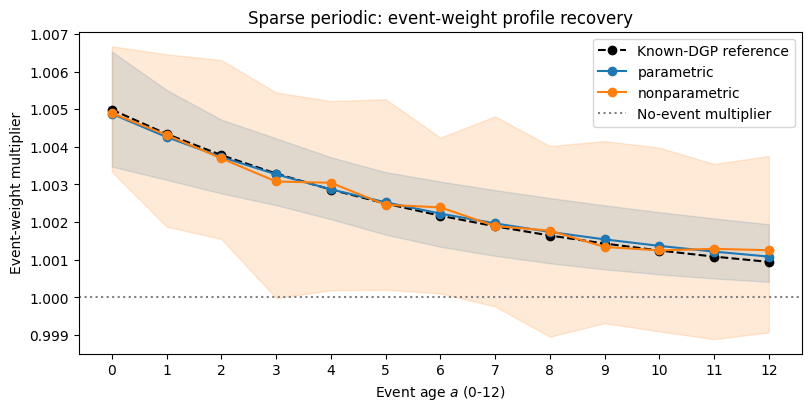

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00978,-0.00022,35.00000,33.34157,-1.65843,0.00055,0.00145


In [10]:
display(Markdown("### Step 3 - Event-weight recovery"))
show_profile('sparse_periodic')

### Step 4 - Volatility forecasting

### Step 5 - Prediction accuracy and calibration

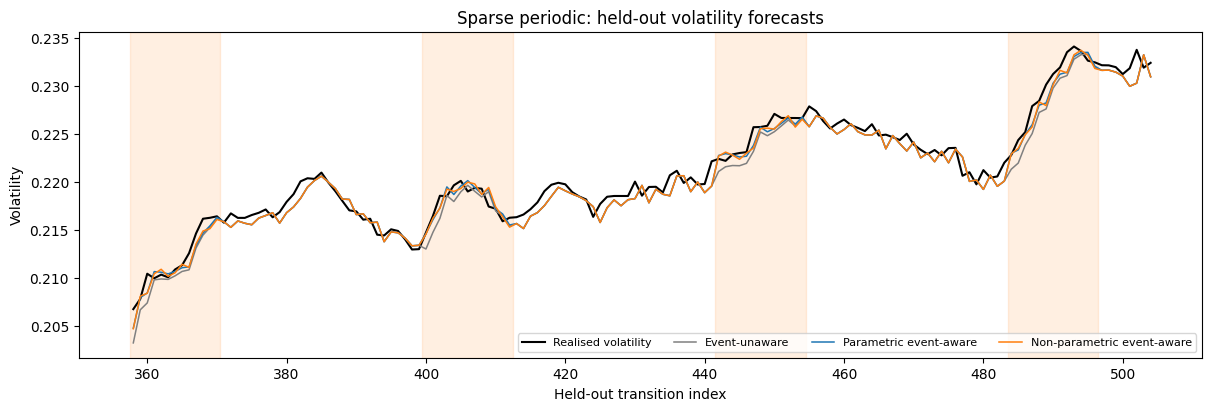

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0011,0.0009,0.0009,19.0049,15.7227,0.9500,0.0286,0.0042


In [11]:
display(Markdown("### Step 4 - Volatility forecasting\n\n### Step 5 - Prediction accuracy and calibration"))
show_forecast('sparse_periodic')

Sparse-periodic finding: the corrected tables distinguish cumulative GC order p from individual conditional lag j. Wider TDMI features remain dependence summaries, not structural timing claims.

## 4. Sparse irregular analysis

Sparse irregular also has 12 events and retains a nominal period of 42 transitions, but realised spacing ranges from 21 to 69 transitions (median 34). There is no single irregular next-event boundary: wider-lag peaks are reported descriptively.

### Step 1 - GC and TDMI analysis

Reverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

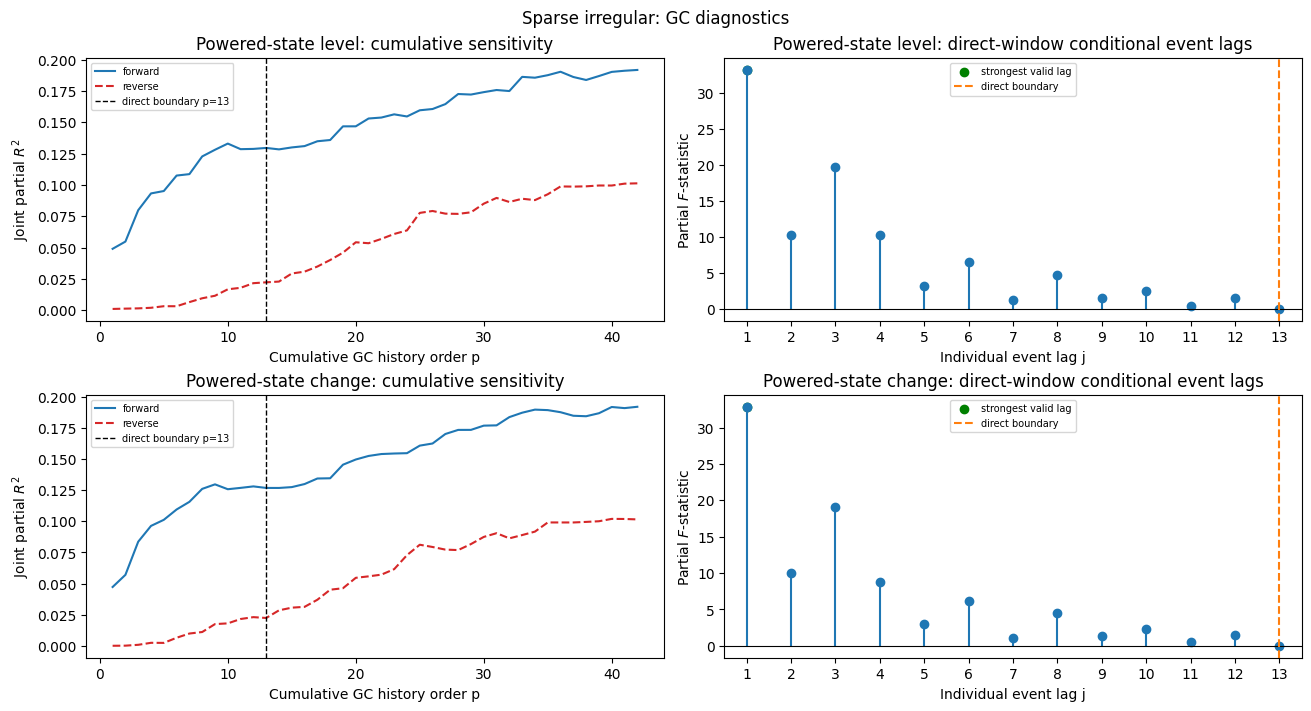

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,8,4,42,11.3369,0.0000,0.0932
1,level,reverse,1,1,42,0.4653,0.4955,0.0010
2,change,forward,8,3,42,13.4467,0.0000,0.0836
3,change,reverse,1,1,40,0.0143,0.9048,0.0000


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0017,33.1488,0.0000,0.0000,True
1,change,1,0.0017,32.8613,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,5.5000,1.0000,0.9000,0.0347,2.0000,19.1789,0.9800
1,level,6.0000,1.0000,0.9000,0.0327,2.0000,18.6905,1.0000


lag,1,2,3,4,5,7,13
target,,,,,,,
change,20,15,7,4,2,1,1
level,21,15,7,4,2,0,1


In [12]:
display(Markdown("### Step 1 - GC and TDMI analysis\n\nReverse GC asks whether past volatility information improves linear prediction of the event indicator beyond its own history. It is a linear predictive diagnostic for a predetermined binary calendar, not structural causality."))
show_gc('sparse_irregular')

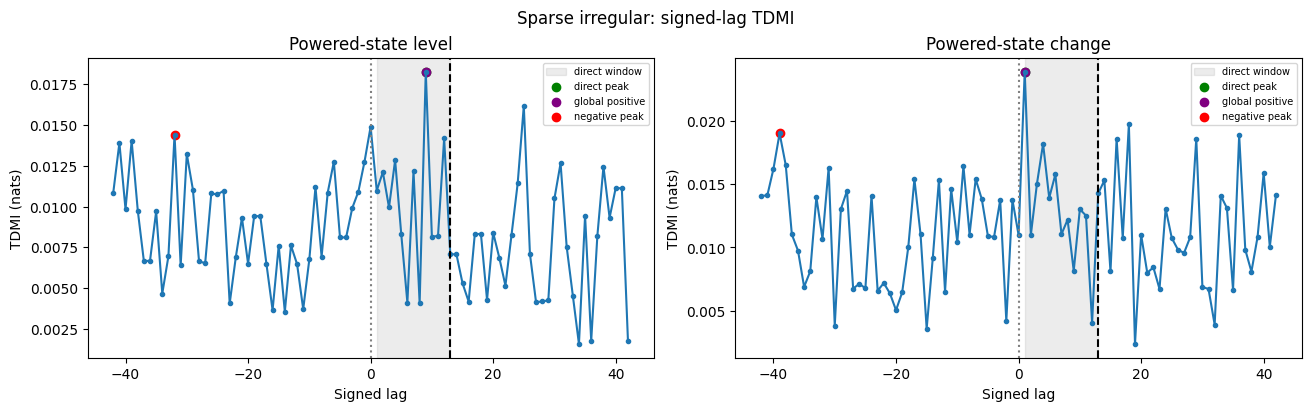

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,9,0.0183,9,0.0183,-32,True,False
1,change,1,0.0239,1,0.0239,-39,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.7000,0.3000,0.8666
1,level,0.3400,0.6600,1.1388


In [13]:
show_tdmi('sparse_irregular')

### Step 3 - Event-weight recovery

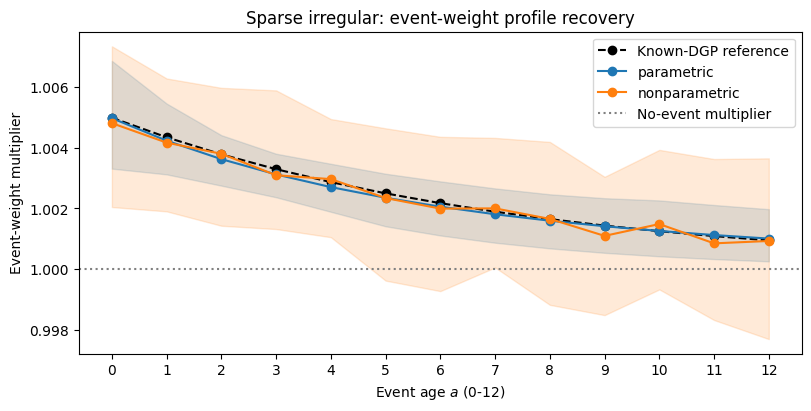

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00997,-0.00003,35.00000,37.98173,2.98173,0.00058,0.00149


In [14]:
display(Markdown("### Step 3 - Event-weight recovery"))
show_profile('sparse_irregular')

### Step 4 - Volatility forecasting

### Step 5 - Prediction accuracy and calibration

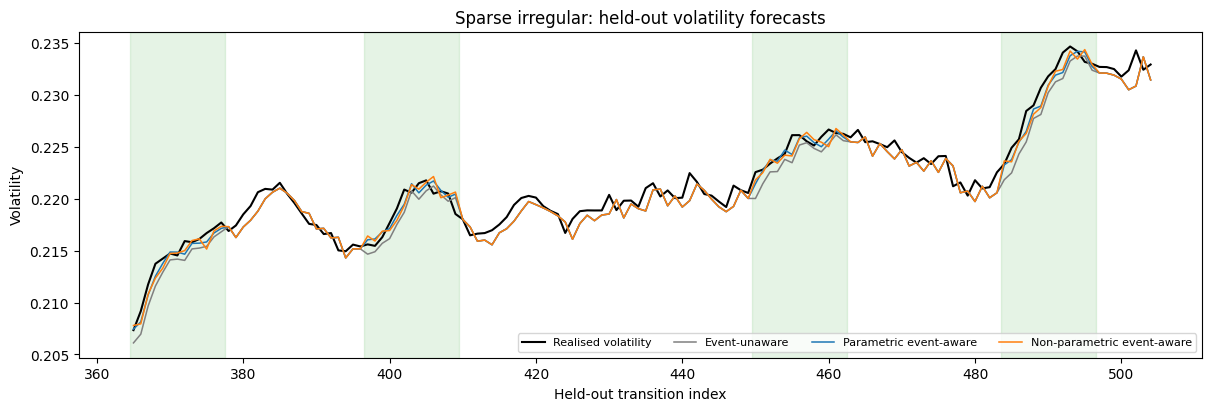

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0008,0.0011,0.0009,0.0009,18.9434,13.4209,0.9392,0.0269,0.0043


In [15]:
display(Markdown("### Step 4 - Volatility forecasting\n\n### Step 5 - Prediction accuracy and calibration"))
show_forecast('sparse_irregular')

Sparse-irregular finding: interpret wider-lag features descriptively because this schedule has no single deterministic next-event boundary. TDMI remains unsigned nonlinear lagged dependence rather than directional causality.

## 5. Final comparison across schedules

Only after the three case studies, the table and two figures summarise the paired repeated evidence. Sparse periodic minus dense periodic changes frequency, spacing and event count; sparse irregular minus sparse periodic is the schedule-regularity comparison.

,schedule,forward GC rejection,reverse GC rejection,median forward partial R2,median reverse partial R2,median AIC order,median BIC order,modal strongest lag,Holm survival rate,global positive TDMI inside direct,outside-window dominance,median outside/direct ratio,parametric profile RMSE,non-parametric profile RMSE,parametric active MAE gain,non-parametric active MAE gain,coverage error,interval score
0,Dense periodic,0.9800,0.4200,0.0753,0.0061,6.0000,2.0000,1,1.0000,0.2800,0.7200,1.0758,0.0003,0.0010,25.1875,22.1318,0.0259,0.0042
1,Sparse periodic,0.9400,0.0600,0.0271,0.0009,6.0000,1.0000,1,0.9600,0.8000,0.2000,0.9120,0.0005,0.0014,19.0049,15.7227,0.0286,0.0042
2,Sparse irregular,0.9000,0.0200,0.0347,0.0009,5.5000,1.0000,1,0.9800,0.7000,0.3000,0.8666,0.0006,0.0015,18.9434,13.4209,0.0269,0.0043


,contrast,metric,paired mean difference,95% CI lower,95% CI upper
0,Sparse periodic minus dense periodic,parametric profile RMSE,0.00021,0.00011,0.00030
1,Sparse periodic minus dense periodic,parametric MAE gain,-5.38569,-7.34039,-3.43099
2,Sparse irregular minus sparse periodic,parametric profile RMSE,0.00003,-0.00008,0.00014
3,Sparse irregular minus sparse periodic,parametric MAE gain,-0.69936,-2.67377,1.27505


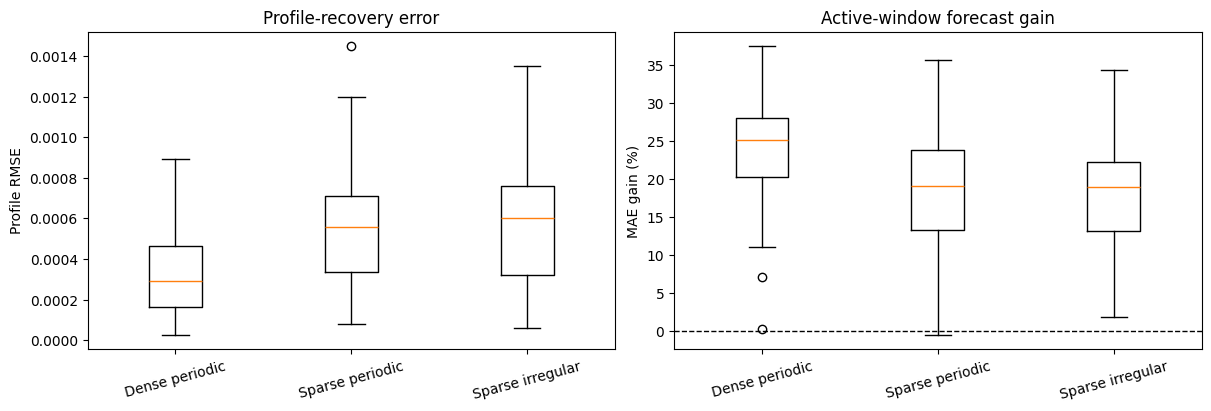

Corrected repeated-seed summary: forward GC rejection is 98%, 94%, and 90%. The two paired contrasts above separate the combined frequency/spacing comparison from the schedule-regularity comparison; reverse GC and TDMI remain predictive/dependence diagnostics.

In [16]:
def paired_ci(values):
    x=np.asarray(values,float); mean=x.mean(); se=x.std(ddof=1)/np.sqrt(len(x)); h=stats.t.ppf(.975,len(x)-1)*se; return mean,mean-h,mean+h
def final_row(case):
    g=gc_repeated.query('case==@case and target=="change" and valid_rank'); selected=g.groupby('seed').apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series); ind=individual_repeated.query('case==@case and target=="change"').sort_values('partial_F').groupby('seed',group_keys=False).tail(1); td=tdmi_repeated.query('case==@case and target=="change"'); pr=profile_repeated.query('case_name==@case'); fo=forecast_repeated.query('case_name==@case'); ca=calibration_repeated.query('case_name==@case'); reverse=gc_repeated.query('case==@case and target=="change" and direction=="reverse" and valid_rank').groupby('seed').apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series)
    return {'schedule':LABEL[case],'forward GC rejection':(selected['joint p']<.05).mean(),'reverse GC rejection':(reverse['joint p']<.05).mean(),'median forward partial R2':selected['partial R2'].median(),'median reverse partial R2':reverse['partial R2'].median(),'median AIC order':selected['AIC order'].median(),'median BIC order':selected['BIC order'].median(),'modal strongest lag':ind.lag.mode().iat[0],'Holm survival rate':ind.holm_reject.mean(),'global positive TDMI inside direct':td.global_positive_inside_direct.mean(),'outside-window dominance':td.alias_dominates.mean(),'median outside/direct ratio':td.alias_strength_ratio.median(),'parametric profile RMSE':pr.parametric_profile_RMSE.mean(),'non-parametric profile RMSE':pr.nonparametric_profile_RMSE.mean(),'parametric active MAE gain':fo.active_sigma_parametric_MAE_gain_pct.median(),'non-parametric active MAE gain':fo.active_sigma_nonparametric_MAE_gain_pct.median(),'coverage error':ca.parametric_absolute_coverage_error.mean(),'interval score':ca.active_95_state_parametric_interval_score.mean()}
final=pd.DataFrame([final_row(k) for k in LABEL]); display(final.style.format(precision=4))
contrast_rows=[]
for name,left,right in [('Sparse periodic minus dense periodic','sparse_periodic','dense_periodic'),('Sparse irregular minus sparse periodic','sparse_irregular','sparse_periodic')]:
    for metric,source in [('parametric profile RMSE',profile_repeated),('parametric MAE gain',forecast_repeated)]:
        col='parametric_profile_RMSE' if metric.startswith('parametric profile') else 'active_sigma_parametric_MAE_gain_pct'; wide=source.pivot(index='market_seed',columns='case_name',values=col); m,lo,hi=paired_ci(wide[left]-wide[right]); contrast_rows.append({'contrast':name,'metric':metric,'paired mean difference':m,'95% CI lower':lo,'95% CI upper':hi})
display(pd.DataFrame(contrast_rows).style.format(precision=5))
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for ax,source,col,title,ylabel in zip(axes,[profile_repeated,forecast_repeated],['parametric_profile_RMSE','active_sigma_parametric_MAE_gain_pct'],['Profile-recovery error','Active-window forecast gain'],['Profile RMSE','MAE gain (%)']): ax.boxplot([source.query('case_name==@k')[col] for k in LABEL],tick_labels=[LABEL[k] for k in LABEL]); ax.axhline(0,color='black',ls='--',lw=1) if 'gain' in col else None; ax.set(title=title,ylabel=ylabel); ax.tick_params(axis='x',rotation=15)
plt.show()
fd=final.set_index('schedule'); display(Markdown(f"Corrected repeated-seed summary: forward GC rejection is {fd.loc['Dense periodic','forward GC rejection']:.0%}, {fd.loc['Sparse periodic','forward GC rejection']:.0%}, and {fd.loc['Sparse irregular','forward GC rejection']:.0%}. The two paired contrasts above separate the combined frequency/spacing comparison from the schedule-regularity comparison; reverse GC and TDMI remain predictive/dependence diagnostics."))

## 6. Concise findings and limitations

The event-response function and scalar parameters remain fixed, and the schedules are synthetic. Conclusions depend on the selected spacing designs. Reverse GC with a binary predetermined calendar is only a linear predictive diagnostic; GC and TDMI do not prove structural causality, and forecast improvement does not guarantee accurate event-profile recovery.

In [17]:
assert all(no_overlap(v) for v in STEPS_BY_CASE.values())
assert gc_repeated.groupby(['case','target','direction']).size().eq(N_SEEDS*P_INDIVIDUAL).all()
assert gc_design_diagnostics.valid_rank.all() and individual_repeated.individual_order.eq(P_INDIVIDUAL).all()
assert individual_repeated.partial_F.ge(0).all() and individual_repeated.p_value.between(0,1).all()
assert GC_PMAX=={'dense_periodic':20,'sparse_periodic':41,'sparse_irregular':42}
assert len(tdmi_repeated)==300 and tdmi_repeated.global_positive_inside_direct.isin([True,False]).all() and tdmi_repeated.alias_dominates.isin([True,False]).all()
assert set(final.schedule)==set(LABEL.values()) and not final.isna().any().any()
print('Notebook 10 executed with corrected explicit forward and reverse GC targets, full-rank direct-window individual tests, canonical repeated summaries, and no stale outputs.')

Notebook 10 executed with corrected explicit forward and reverse GC targets, full-rank direct-window individual tests, canonical repeated summaries, and no stale outputs.
